In [1]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from mplsoccer import VerticalPitch
from statsbombpy import sb
import time


sys.path.append("../")
from xThreat import xThreat

In [2]:
n_x = 16
n_y = 12

In [3]:
xT_true_16x12 = xThreat.load_from_pickle(f'../0-model-storage/xt-full-data-n_x{16}-n_y{12}.pickle')
xT_true_32x24 = xThreat.load_from_pickle(f'../0-model-storage/xt-full-data-n_x{32}-n_y{24}.pickle')
xT_true_64x48 = xThreat.load_from_pickle(f'../0-model-storage/xt-full-data-n_x{64}-n_y{48}.pickle')


In [4]:
df_euros = pd.read_parquet('../1-data-preparation/data-storage/xThreat_datav3_euros2020.parquet')

In [5]:
df_euros.describe()

,x,y,possession,possession_length,chain_length,match_id,period,player_id,shot_statsbomb_xg,under_pressure,next_x,next_y,next_under_pressure,next_team_id,next_player_id
count,92654.000000,92654.000000,92654.000000,92654.000000,92654.000000,9.265400e+04,92654.000000,92654.000000,619.000000,20416.0,92654.000000,92654.000000,20407.0,92654.000000,92654.000000
mean,51.333875,33.650458,89.303743,12.809172,8.329559,3.790811e+06,1.574417,10128.393291,0.140505,1.0,51.345598,33.648096,1.0,886.433538,10129.786906
std,23.291350,19.858639,55.170866,13.628198,10.101545,2.917399e+03,0.660055,8483.507971,0.196433,0.0,23.296198,19.857529,0.0,273.628451,8485.351214
min,0.350000,0.085000,2.000000,0.000000,0.000000,3.788741e+06,1.000000,2954.000000,0.004871,1.0,0.350000,0.085000,1.0,768.000000,2954.000000
25%,35.087500,16.171250,43.000000,3.000000,1.000000,3.788754e+06,1.000000,4870.000000,0.035180,1.0,35.175000,16.235000,1.0,772.000000,4870.000000
50%,50.925000,33.405000,85.000000,8.000000,5.000000,3.788767e+06,2.000000,6954.000000,0.060380,1.0,50.925000,33.405000,1.0,785.000000,6954.000000
75%,68.250000,51.085000,131.000000,18.000000,12.000000,3.794688e+06,2.000000,11514.000000,0.139786,1.0,68.250000,51.085000,1.0,912.000000,11514.000000
max,104.650000,67.915000,275.000000,119.000000,103.000000,3.795506e+06,5.000000,73852.000000,0.963011,1.0,104.650000,67.915000,1.0,2358.000000,73852.000000


# Filter on players with at least 300 minutes

## Find minutes per player

In [6]:
player_ids = df_euros['player_id'].unique().tolist()
position_mapping = {
    'Goalkeeper': 'Goalkeeper',
    'Right Back': 'Defender', 'Left Back': 'Defender', 'Center Back': 'Defender', 'Right Center Back': 'Defender', 'Left Center Back': 'Defender',
    'Right Wing Back': 'Defender', 'Left Wing Back': 'Defender', 
    'Center Defensive Midfield': 'Midfielder', 'Left Defensive Midfield': 'Midfielder', 'Right Defensive Midfield': 'Midfielder',
    'Central Midfield': 'Midfielder', 
    'Center Attacking Midfield': 'Midfielder', 'Right Attacking Midfield': 'Midfielder', 'Left Attacking Midfield': 'Midfielder',
    'Left Center Forward': 'Attacker', 'Right Center Forward': 'Attacker',
    'Right Midfield': 'Midfielder', 'Left Midfield': 'Midfielder', 'Right Center Midfield': 'Midfielder', 'Left Center Midfield': 'Midfielder',
    'Right Wing': 'Attacker', 'Left Wing': 'Attacker', 'Center Forward': 'Attacker', 'Second Striker': 'Attacker'
}

In [7]:
# Get all competitions and find UEFA Euro 2020
competitions = sb.competitions()
euro_2020 = competitions[
    (competitions['competition_name'] == 'UEFA Euro') & (competitions['season_name'] == '2020')
]
competition_id = euro_2020.iloc[0]['competition_id']
season_id = euro_2020.iloc[0]['season_id']

# Get all matches
matches = sb.matches(competition_id=competition_id, season_id=season_id)
match_ids = matches['match_id'].tolist()

# Dictionary to store player minutes
player_minutes = {}

# Dictionary to store player positions
player_positions = {}

# Dictionary to store player names for each id
player_ids = {}

# Loop through each match
for match_id in match_ids:
    events = sb.events(match_id)
    
    # Get match duration (accounting for extra time)
    max_minute = events['minute'].max()

    # Track player substitutions
    player_in_times = {}  # {player_name: entry_minute}
    player_out_times = {} # {player_name: exit_minute}

    for _, event in events.iterrows():
        if event['type'] == 'Substitution':
            player_off = event['player']
            player_on = event['substitution_replacement']
            minute = event['minute']

            if player_off:
                player_out_times[player_off] = minute
            if player_on:
                player_in_times[player_on] = minute

    # Calculate minutes for all players
    for player in events['player'].dropna().unique():
        start_minute = player_in_times.get(player, 0)  # Defaults to starting lineup (0 min)
        end_minute = player_out_times.get(player, max_minute)  # Defaults to full game

        minutes_played = end_minute - start_minute
        player_minutes[player] = player_minutes.get(player, 0) + minutes_played

    # Get lineup data for this match
    lineup_data = sb.lineups(match_id)

    # Extract player positions (lineup_data is a dictionary of DataFrames)
    for team_name, lineup_df in lineup_data.items():
        for _, player in lineup_df.iterrows():
            player_name = player['player_name']
            player_id = player['player_id']
            player_ids[player_name] = player_id

            game_player_positions = player_positions.get(player_name, {'Goalkeeper': 0, 'Defender': 0, 'Midfielder': 0, 'Attacker': 0})
            for position in player['positions']:
                game_player_positions[position_mapping[position['position']]] += 1
                
            player_positions[player_name] = game_player_positions

# Convert minutes to DataFrame
players_df = pd.DataFrame(player_minutes.items(), columns=['Player', 'Minutes'])

player_ids = pd.DataFrame(player_ids.items(), columns = ['Player', 'player_id'])

# Convert positions to DataFrame
player_names = player_positions.keys()
goalkeeper, defender, midfielder, attacker = [], [], [], []
for player_name in player_names:
    goalkeeper.append(player_positions[player_name]['Goalkeeper'])
    defender.append(player_positions[player_name]['Defender'])
    midfielder.append(player_positions[player_name]['Midfielder'])
    attacker.append(player_positions[player_name]['Attacker'])

positions_df = pd.DataFrame({
    'Player': player_names,
    'goalkeeper': goalkeeper,
    'defender': defender,
    'midfielder': midfielder,
    'attacker': attacker,
})
positions_df["main_position"] = positions_df[["goalkeeper", "defender", "midfielder", "attacker"]].idxmax(axis=1)


# Merge DataFrames
players_df = players_df.merge(positions_df, on='Player', how='left')
players_df = players_df.merge(player_ids, on='Player', how='left')

# Filter for players with at least 300 minutes
filtered_players = players_df[players_df['Minutes'] >= 300]

filtered_players.head()

,Player,Minutes,goalkeeper,defender,midfielder,attacker,main_position,player_id
0,Álvaro Borja Morata Martín,455,0,0,0,8,attacker,3477
1,Pau Francisco Torres,395,0,10,0,0,defender,6892
2,Aymeric Laporte,658,0,12,0,0,defender,4353
3,Jordi Alba Ramos,581,0,6,0,0,defender,5211
5,Jorge Resurrección Merodio,483,0,0,6,0,midfielder,5199


## Distribution of minutes over players

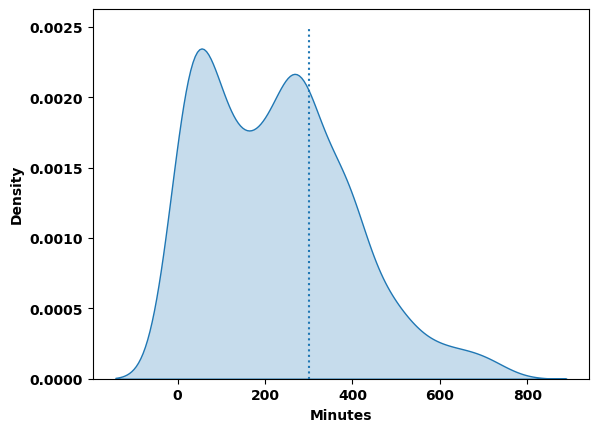

In [8]:
ax = sns.kdeplot(data=players_df, x='Minutes', fill=True)
ax.plot([300, 300], [0,0.0025], ":")
plt.show()

# Filter on players with at least 300 minutes

In [9]:
filtered_player_ids = filtered_players['player_id']
mask = df_euros['player_id'].isin(filtered_player_ids)
df_euros_filtered = df_euros[mask].copy()
df_euros_filtered

,x,y,possession_kept,possession,possession_length,chain_length,previous_deleted,match_id,id,period,...,shot_outcome,shot_statsbomb_xg,pass_height,under_pressure,next_type,next_x,next_y,next_under_pressure,next_team_id,next_player_id
index,,,,,,,,,,,,,,,,,,,,,
2088,13.8250,6.375,True,3,0,0,True,3788741,4cbd1088-1580-43f5-8b09-58efabb753ff,1,...,None,NaN,None,NaN,Pass,2.8875,10.795,NaN,914.0,6954.0
9,2.8875,10.795,True,3,2,1,False,3788741,bfcfd5ad-1dda-44c9-9f3d-9b33b59983a6,1,...,None,NaN,Ground Pass,NaN,Carry,6.9125,30.770,NaN,914.0,7036.0
2089,6.9125,30.770,True,3,3,2,False,3788741,58ef2997-552a-4d3e-854a-cf863f9f5b71,1,...,None,NaN,None,NaN,Pass,7.9625,33.065,NaN,914.0,7036.0
10,7.9625,33.065,True,3,4,3,False,3788741,14604dfa-65b1-40c0-a11e-7c6b037806c0,1,...,None,NaN,Ground Pass,NaN,Carry,17.2375,40.715,NaN,914.0,7173.0
2090,17.2375,40.715,True,3,5,4,False,3788741,5eae5d7a-59cb-42e0-bfc0-c5a2e80493ee,1,...,None,NaN,None,NaN,Pass,25.2000,42.415,NaN,914.0,7173.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3783,88.3750,66.045,True,210,20,20,False,3795506,d554972c-7ce9-4698-84e9-fb2b01fbfd97,4,...,None,NaN,None,NaN,Pass,71.0500,44.710,1.0,768.0,10955.0
1358,71.0500,44.710,False,211,0,0,True,3795506,22f76976-9167-4bc4-9ccb-66560d849b4a,4,...,None,NaN,High Pass,1.0,Shot,94.5000,34.000,NaN,768.0,10955.0
4382,94.5000,34.000,False,214,0,0,True,3795506,526593d2-c545-4433-aa71-f923a7dd7811,5,...,Goal,0.7835,None,NaN,Shot,94.4125,34.000,NaN,914.0,7471.0


# True model 16x12

## Prepare data

In [10]:
# Get xT values
df_euros_filtered['shot'] = ~df_euros_filtered['shot_outcome'].isna()
df_euros_filtered['goal'] = df_euros_filtered['shot_outcome'] == 'Goal'
df_euros_filtered = xT_true_16x12.quantify_action_quality(df_euros_filtered)

In [11]:
# Filter for positive xT actions
df_positive = df_euros_filtered[df_euros_filtered['action_xT'] > 0]

# Calculate action xT per player
player_xT_df = df_positive.groupby('player_id').agg(
    action_xT_sum=('action_xT', 'sum'),
    action_count=('action_xT', 'count'),
).reset_index()

# Add information like player name, minutes, and position
player_xT_df = player_xT_df.merge(filtered_players[['player_id', 'Player', 'Minutes', 'main_position']], on='player_id', how='left')

# Calculate action xT per 90 minutes
player_xT_df['action_xT_per_90'] = player_xT_df['action_xT_sum'] / player_xT_df['Minutes'] * 90

# Sort players by action xT
player_xT_df = player_xT_df.sort_values('action_xT_per_90')

# Filter midfielders
midfielder_xT_df = player_xT_df[player_xT_df['main_position'] == 'midfielder'].sort_values('action_xT_per_90')

midfielder_xT_df

,player_id,action_xT_sum,action_count,Player,Minutes,main_position,action_xT_per_90
121,16514.0,0.232477,117,Serhii Sydorchuk,384,midfielder,0.054487
69,5617.0,0.284656,55,Sebastian Larsson,383,midfielder,0.066890
72,5624.0,0.337610,76,Albin Ekdal,402,midfielder,0.075584
33,3961.0,0.349330,190,N''Golo Kanté,415,midfielder,0.075758
40,4870.0,0.408551,155,Tomáš Souček,471,midfielder,0.078067
38,4706.0,0.618223,186,Kalvin Phillips,685,midfielder,0.081226
111,10931.0,0.341527,97,Joe Allen,349,midfielder,0.088073
30,3943.0,0.531382,247,Declan Rice,541,midfielder,0.088400
75,5642.0,0.320679,147,Axel Witsel,322,midfielder,0.089631
81,6983.0,0.604207,169,Remo Freuler,526,midfielder,0.103381


## Beeswarmplot all players

146


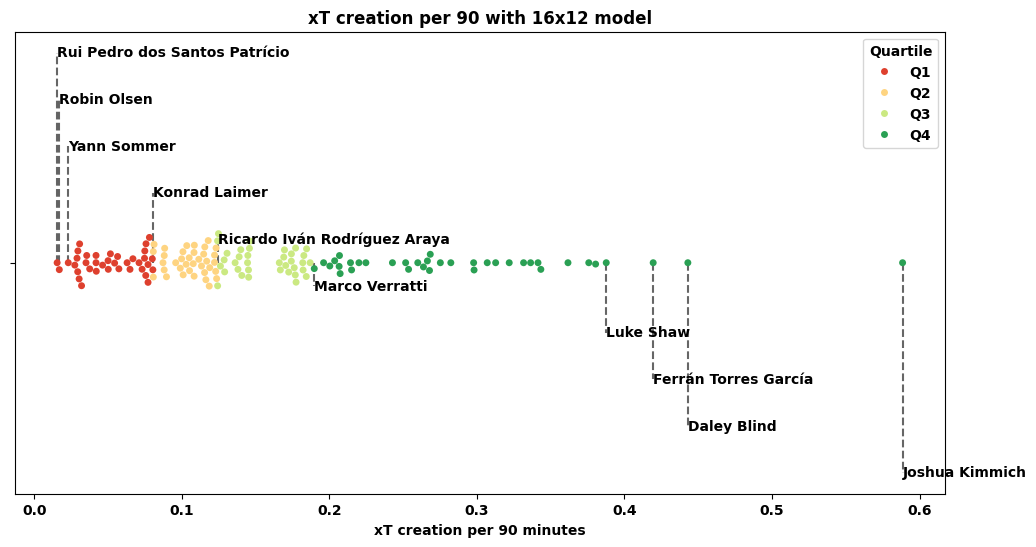

In [12]:
# Determine quartile thresholds
q1 = player_xT_df['action_xT_per_90'].quantile(0.25)
q2 = player_xT_df['action_xT_per_90'].quantile(0.5)
q3 = player_xT_df['action_xT_per_90'].quantile(0.75)

# Assign colors based on quartiles
def assign_quartile(value):
    if value <= q1:
        return 'Q1'
    elif value <= q2:
        return 'Q2'
    elif value <= q3:
        return 'Q3'
    else:
        return 'Q4'
    
cm = matplotlib.colormaps.get_cmap('RdYlGn')
palette_quartile = {
           'Q1': cm(0.125),
           'Q2': cm(0.375),
           'Q3': cm(0.625),
           'Q4': cm(0.875),
           }

print(player_xT_df['Player'].nunique())
player_xT_df['Quartile'] = player_xT_df['action_xT_per_90'].apply(assign_quartile)

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(player_xT_df) // 4, len(player_xT_df) // 2, 3 * len(player_xT_df) // 4, len(player_xT_df) - 4, len(player_xT_df) - 3, len(player_xT_df) - 2, len(player_xT_df) - 1]
key_players = player_xT_df.iloc[key_indices]

# Create beeswarm plot
plt.figure(figsize=(12, 6))
ax = sns.swarmplot(x=player_xT_df['action_xT_per_90'], orient='h', size=5, hue=player_xT_df['Quartile'], palette=palette_quartile)

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    plt.plot([row['action_xT_per_90'], row['action_xT_per_90']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    plt.text(row['action_xT_per_90'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

plt.xlabel('xT creation per 90 minutes')
plt.title('xT creation per 90 with 16x12 model')
plt.show()

## Beeswarmplot midfielders

There are 41 unique midfielders in this data set.


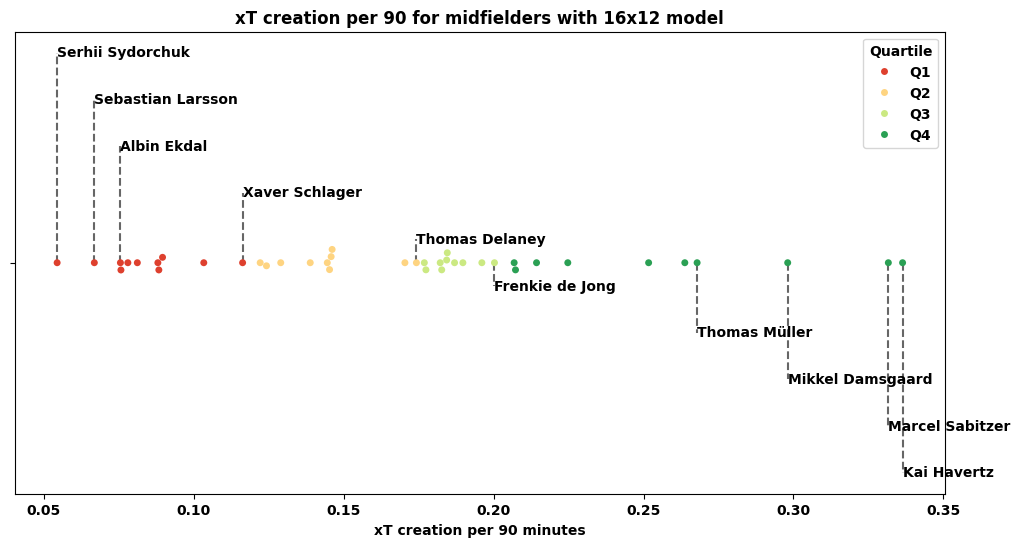

In [13]:
# Determine quartile thresholds
q1 = midfielder_xT_df['action_xT_per_90'].quantile(0.25)
q2 = midfielder_xT_df['action_xT_per_90'].quantile(0.5)
q3 = midfielder_xT_df['action_xT_per_90'].quantile(0.75)

# Assign colors based on quartiles
def assign_quartile(value):
    if value <= q1:
        return 'Q1'
    elif value <= q2:
        return 'Q2'
    elif value <= q3:
        return 'Q3'
    else:
        return 'Q4'
    
cm = matplotlib.colormaps.get_cmap('RdYlGn')
palette_quartile = {
           'Q1': cm(0.125),
           'Q2': cm(0.375),
           'Q3': cm(0.625),
           'Q4': cm(0.875),
           }

print(f"There are {midfielder_xT_df['Player'].nunique()} unique midfielders in this data set.")
midfielder_xT_df['Quartile'] = midfielder_xT_df['action_xT_per_90'].apply(assign_quartile)

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(midfielder_xT_df) // 4, len(midfielder_xT_df) // 2, 3 * len(midfielder_xT_df) // 4, len(midfielder_xT_df) - 4, len(midfielder_xT_df) - 3, len(midfielder_xT_df) - 2, len(midfielder_xT_df) - 1]
key_players = midfielder_xT_df.iloc[key_indices]

# Create beeswarm plot
plt.figure(figsize=(12, 6))
ax = sns.swarmplot(x=midfielder_xT_df['action_xT_per_90'], orient='h', size=5, hue=midfielder_xT_df['Quartile'], palette=palette_quartile)

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    plt.plot([row['action_xT_per_90'], row['action_xT_per_90']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    plt.text(row['action_xT_per_90'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

plt.xlabel('xT creation per 90 minutes')
plt.title('xT creation per 90 for midfielders with 16x12 model')
plt.show()

## Distance to quartiles

In [14]:
Q1_max = midfielder_xT_df[midfielder_xT_df['Quartile'] == 'Q1']['action_xT_per_90'].max()
Q2_min = midfielder_xT_df[midfielder_xT_df['Quartile'] == 'Q2']['action_xT_per_90'].min()
Q2_max = midfielder_xT_df[midfielder_xT_df['Quartile'] == 'Q2']['action_xT_per_90'].max()
Q3_min = midfielder_xT_df[midfielder_xT_df['Quartile'] == 'Q3']['action_xT_per_90'].min()
Q3_max = midfielder_xT_df[midfielder_xT_df['Quartile'] == 'Q3']['action_xT_per_90'].max()
Q4_min = midfielder_xT_df[midfielder_xT_df['Quartile'] == 'Q4']['action_xT_per_90'].min()
print(f'Q1: (-inf, {Q1_max:.3f}], [{Q2_min:.3f}, {Q2_max:.3f}], [{Q3_min:.3f}, {Q3_max:.3f}], [{Q4_min:.3f}, inf)')

Q1: (-inf, 0.116], [0.122, 0.174], [0.177, 0.200], [0.207, inf)


In [15]:
midfielder_xT_df.loc[midfielder_xT_df['Quartile'] == 'Q1', 'Distance to different quartile'] = Q2_min - midfielder_xT_df['action_xT_per_90']
midfielder_xT_df.loc[midfielder_xT_df['Quartile'] == 'Q2', 'Distance to different quartile'] = np.minimum(midfielder_xT_df['action_xT_per_90'] - Q1_max, Q3_min - midfielder_xT_df['action_xT_per_90'])
midfielder_xT_df.loc[midfielder_xT_df['Quartile'] == 'Q3', 'Distance to different quartile'] = np.minimum(midfielder_xT_df['action_xT_per_90'] - Q2_max, Q4_min - midfielder_xT_df['action_xT_per_90'])
midfielder_xT_df.loc[midfielder_xT_df['Quartile'] == 'Q4', 'Distance to different quartile'] = midfielder_xT_df['action_xT_per_90'] - Q3_max
midfielder_xT_df

,player_id,action_xT_sum,action_count,Player,Minutes,main_position,action_xT_per_90,Quartile,Distance to different quartile
121,16514.0,0.232477,117,Serhii Sydorchuk,384,midfielder,0.054487,Q1,0.067701
69,5617.0,0.284656,55,Sebastian Larsson,383,midfielder,0.066890,Q1,0.055297
72,5624.0,0.337610,76,Albin Ekdal,402,midfielder,0.075584,Q1,0.046603
33,3961.0,0.349330,190,N''Golo Kanté,415,midfielder,0.075758,Q1,0.046429
40,4870.0,0.408551,155,Tomáš Souček,471,midfielder,0.078067,Q1,0.044121
38,4706.0,0.618223,186,Kalvin Phillips,685,midfielder,0.081226,Q1,0.040961
111,10931.0,0.341527,97,Joe Allen,349,midfielder,0.088073,Q1,0.034115
30,3943.0,0.531382,247,Declan Rice,541,midfielder,0.088400,Q1,0.033788
75,5642.0,0.320679,147,Axel Witsel,322,midfielder,0.089631,Q1,0.032557
81,6983.0,0.604207,169,Remo Freuler,526,midfielder,0.103381,Q1,0.018806


In [16]:
print(f"(Sanity check:) Number of nan values in distance is {midfielder_xT_df['Distance to different quartile'].isna().sum()}")
midfielder_xT_df.sort_values('Distance to different quartile')

(Sanity check:) Number of nan values in distance is 0


,player_id,action_xT_sum,action_count,Player,Minutes,main_position,action_xT_per_90,Quartile,Distance to different quartile
55,5527.0,0.884938,121,Thomas Delaney,457,midfielder,0.174277,Q2,0.002638
128,20004.0,0.776459,189,Paul Pogba,395,midfielder,0.176915,Q3,0.002638
54,5487.0,0.719634,116,Antoine Griezmann,365,midfielder,0.177444,Q3,0.003167
101,8769.0,0.483402,127,Xaver Schlager,374,midfielder,0.116327,Q1,0.005861
135,22074.0,0.418153,88,Joseff Morrell,308,midfielder,0.122188,Q2,0.005861
133,21294.0,0.617368,167,Mykola Shaparenko,326,midfielder,0.170439,Q2,0.006476
93,8118.0,0.807883,221,Frenkie de Jong,363,midfielder,0.200301,Q3,0.006564
92,7843.0,1.075699,98,Mason Mount,468,midfielder,0.206865,Q4,0.006564
22,3517.0,0.836163,76,Aaron Ramsey,363,midfielder,0.207313,Q4,0.007012
119,16469.0,0.611412,72,Tomáš Holeš,302,midfielder,0.182209,Q3,0.007932


In [17]:
midfielder_xT_df['Actions per 90 minutes'] = midfielder_xT_df['action_xT_count'] / midfielder_xT_df['Minutes'] * 90
midfielder_xT_df.describe()

KeyError: 'action_xT_count'

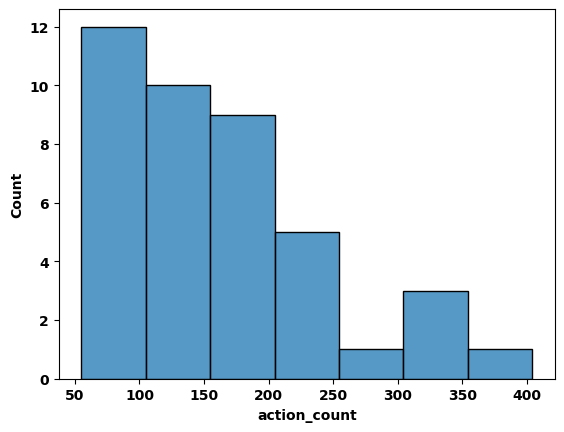

In [ ]:
sns.histplot(midfielder_xT_df['action_count'])
plt.show()

# True model 64x48

## Prepare data

In [ ]:
# Get xT values
df_euros_filtered['shot'] = ~df_euros_filtered['shot_outcome'].isna()
df_euros_filtered['goal'] = df_euros_filtered['shot_outcome'] == 'Goal'
df_euros_filtered_64x48 = xT_true_64x48.quantify_action_quality(df_euros_filtered)

In [ ]:
# Filter for positive xT actions
df_positive_64x48 = df_euros_filtered_64x48[df_euros_filtered_64x48['action_xT'] > 0]

# Calculate action xT per player
player_xT_df_64x48 = df_positive_64x48.groupby('player_id').agg(
    action_xT_sum=('action_xT', 'sum'),
    action_count=('action_xT', 'count'),
).reset_index()

# Add information like player name, minutes, and position
player_xT_df_64x48 = player_xT_df_64x48.merge(filtered_players[['player_id', 'Player', 'Minutes', 'main_position']], on='player_id', how='left')

# Calculate action xT per 90 minutes
player_xT_df_64x48['action_xT_per_90'] = player_xT_df_64x48['action_xT_sum'] / player_xT_df_64x48['Minutes'] * 90

# Sort players by action xT
player_xT_df_64x48 = player_xT_df_64x48.sort_values('action_xT_per_90')

# Filter midfielders
midfielder_xT_df_64x48 = player_xT_df_64x48[player_xT_df_64x48['main_position'] == 'midfielder'].sort_values('action_xT_per_90')

midfielder_xT_df_64x48

,player_id,action_xT_sum,action_count,Player,Minutes,main_position,action_xT_per_90
121,16514.0,0.258518,137,Serhii Sydorchuk,384,midfielder,0.060590
40,4870.0,0.344583,171,Tomáš Souček,471,midfielder,0.065844
72,5624.0,0.326269,85,Albin Ekdal,402,midfielder,0.073045
111,10931.0,0.284928,106,Joe Allen,349,midfielder,0.073477
33,3961.0,0.343316,221,N''Golo Kanté,415,midfielder,0.074454
69,5617.0,0.339113,68,Sebastian Larsson,383,midfielder,0.079687
30,3943.0,0.511670,280,Declan Rice,541,midfielder,0.085121
38,4706.0,0.716079,223,Kalvin Phillips,685,midfielder,0.094083
81,6983.0,0.551668,182,Remo Freuler,526,midfielder,0.094392
101,8769.0,0.416702,141,Xaver Schlager,374,midfielder,0.100276


## Beeswarmplot all players

146


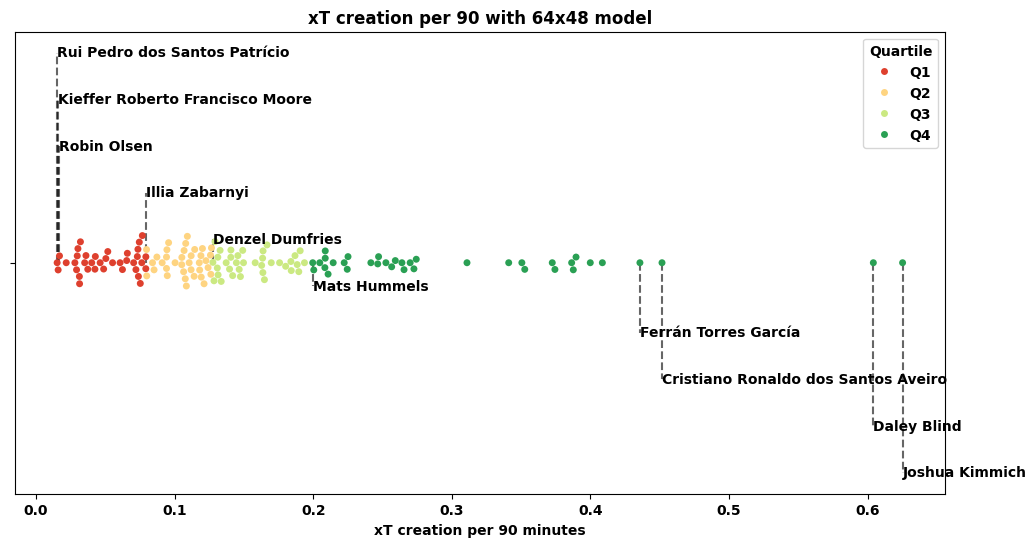

In [ ]:
# Determine quartile thresholds
q1 = player_xT_df_64x48['action_xT_per_90'].quantile(0.25)
q2 = player_xT_df_64x48['action_xT_per_90'].quantile(0.5)
q3 = player_xT_df_64x48['action_xT_per_90'].quantile(0.75)

# Assign colors based on quartiles
def assign_quartile(value):
    if value <= q1:
        return 'Q1'
    elif value <= q2:
        return 'Q2'
    elif value <= q3:
        return 'Q3'
    else:
        return 'Q4'
    
cm = matplotlib.colormaps.get_cmap('RdYlGn')
palette_quartile = {
           'Q1': cm(0.125),
           'Q2': cm(0.375),
           'Q3': cm(0.625),
           'Q4': cm(0.875),
           }

print(player_xT_df_64x48['Player'].nunique())
player_xT_df_64x48['Quartile'] = player_xT_df_64x48['action_xT_per_90'].apply(assign_quartile)

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(player_xT_df_64x48) // 4, len(player_xT_df_64x48) // 2, 3 * len(player_xT_df_64x48) // 4, len(player_xT_df_64x48) - 4, len(player_xT_df_64x48) - 3, len(player_xT_df_64x48) - 2, len(player_xT_df_64x48) - 1]
key_players = player_xT_df_64x48.iloc[key_indices]

# Create beeswarm plot
plt.figure(figsize=(12, 6))
ax = sns.swarmplot(x=player_xT_df_64x48['action_xT_per_90'], orient='h', size=5, hue=player_xT_df_64x48['Quartile'], palette=palette_quartile)

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    plt.plot([row['action_xT_per_90'], row['action_xT_per_90']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    plt.text(row['action_xT_per_90'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

plt.xlabel('xT creation per 90 minutes')
plt.title('xT creation per 90 with 64x48 model')
plt.show()

## Beeswarmplot midfielders

There are 41 unique midfielders in this data set.


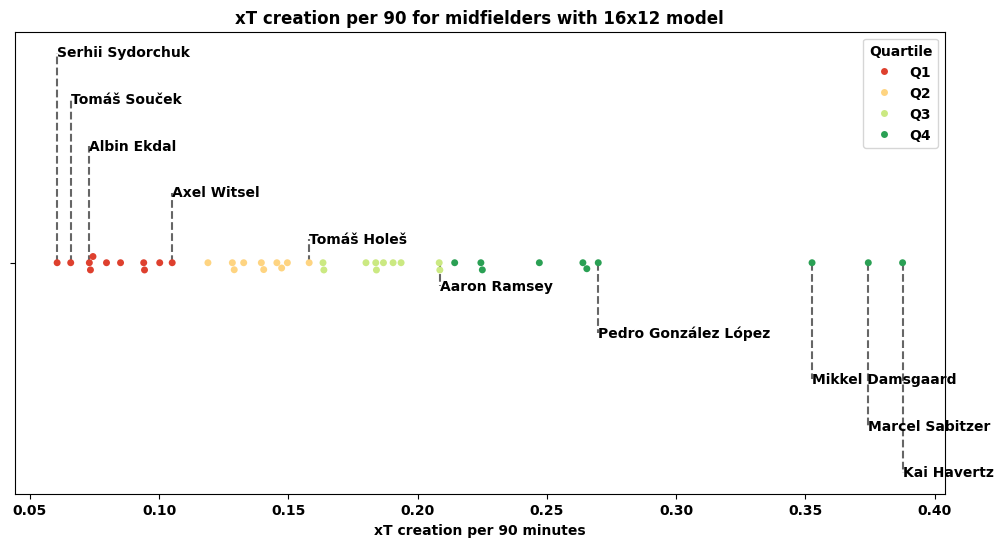

In [ ]:
# Determine quartile thresholds
q1 = midfielder_xT_df_64x48['action_xT_per_90'].quantile(0.25)
q2 = midfielder_xT_df_64x48['action_xT_per_90'].quantile(0.5)
q3 = midfielder_xT_df_64x48['action_xT_per_90'].quantile(0.75)

# Assign colors based on quartiles
def assign_quartile(value):
    if value <= q1:
        return 'Q1'
    elif value <= q2:
        return 'Q2'
    elif value <= q3:
        return 'Q3'
    else:
        return 'Q4'
    
cm = matplotlib.colormaps.get_cmap('RdYlGn')
palette_quartile = {
           'Q1': cm(0.125),
           'Q2': cm(0.375),
           'Q3': cm(0.625),
           'Q4': cm(0.875),
           }

print(f"There are {midfielder_xT_df_64x48['Player'].nunique()} unique midfielders in this data set.")
midfielder_xT_df_64x48['Quartile'] = midfielder_xT_df_64x48['action_xT_per_90'].apply(assign_quartile)

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(midfielder_xT_df_64x48) // 4, len(midfielder_xT_df_64x48) // 2, 3 * len(midfielder_xT_df_64x48) // 4, len(midfielder_xT_df_64x48) - 4, len(midfielder_xT_df_64x48) - 3, len(midfielder_xT_df_64x48) - 2, len(midfielder_xT_df_64x48) - 1]
key_players = midfielder_xT_df_64x48.iloc[key_indices]

# Create beeswarm plot
plt.figure(figsize=(12, 6))
ax = sns.swarmplot(x=midfielder_xT_df_64x48['action_xT_per_90'], orient='h', size=5, hue=midfielder_xT_df_64x48['Quartile'], palette=palette_quartile)

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    plt.plot([row['action_xT_per_90'], row['action_xT_per_90']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    plt.text(row['action_xT_per_90'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

plt.xlabel('xT creation per 90 minutes')
plt.title('xT creation per 90 for midfielders with 16x12 model')
plt.show()

## True model 32x24

## Prepare data

In [ ]:
# Get xT values
df_euros_filtered['shot'] = ~df_euros_filtered['shot_outcome'].isna()
df_euros_filtered['goal'] = df_euros_filtered['shot_outcome'] == 'Goal'
df_euros_filtered_32x24 = xT_true_32x24.quantify_action_quality(df_euros_filtered)

In [ ]:
# Filter for positive xT actions
df_positive_32x24= df_euros_filtered_32x24[df_euros_filtered_32x24['action_xT'] > 0]

# Calculate action xT per player
player_xT_df_32x24 = df_positive_32x24.groupby('player_id').agg(
    action_xT_sum=('action_xT', 'sum'),
    action_count=('action_xT', 'count'),
).reset_index()

# Add information like player name, minutes, and position
player_xT_df_32x24 = player_xT_df_32x24.merge(filtered_players[['player_id', 'Player', 'Minutes', 'main_position']], on='player_id', how='left')

# Calculate action xT per 90 minutes
player_xT_df_32x24['action_xT_per_90'] = player_xT_df_32x24['action_xT_sum'] / player_xT_df_32x24['Minutes'] * 90

# Sort players by action xT
player_xT_df_32x24 = player_xT_df_32x24.sort_values('action_xT_per_90')

# Filter midfielders
midfielder_xT_df_32x24 = player_xT_df_32x24[player_xT_df_32x24['main_position'] == 'midfielder'].sort_values('action_xT_per_90')

midfielder_xT_df_32x24

,player_id,action_xT_sum,action_count,Player,Minutes,main_position,action_xT_per_90
121,16514.0,0.245821,137,Serhii Sydorchuk,384,midfielder,0.057614
72,5624.0,0.281832,83,Albin Ekdal,402,midfielder,0.063097
40,4870.0,0.351416,168,Tomáš Souček,471,midfielder,0.067150
111,10931.0,0.272490,94,Joe Allen,349,midfielder,0.070270
69,5617.0,0.311368,64,Sebastian Larsson,383,midfielder,0.073167
33,3961.0,0.344995,205,N''Golo Kanté,415,midfielder,0.074818
30,3943.0,0.520940,273,Declan Rice,541,midfielder,0.086663
75,5642.0,0.345026,156,Axel Witsel,322,midfielder,0.096436
38,4706.0,0.738957,213,Kalvin Phillips,685,midfielder,0.097089
81,6983.0,0.576468,175,Remo Freuler,526,midfielder,0.098635


## Beeswarmplot all players

146


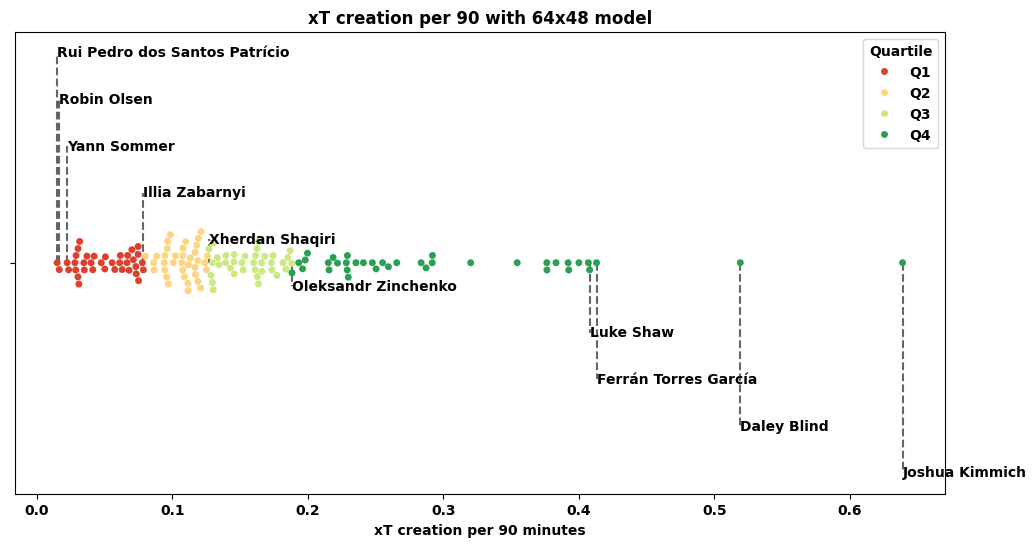

In [ ]:
# Determine quartile thresholds
q1 = player_xT_df_32x24['action_xT_per_90'].quantile(0.25)
q2 = player_xT_df_32x24['action_xT_per_90'].quantile(0.5)
q3 = player_xT_df_32x24['action_xT_per_90'].quantile(0.75)

# Assign colors based on quartiles
def assign_quartile(value):
    if value <= q1:
        return 'Q1'
    elif value <= q2:
        return 'Q2'
    elif value <= q3:
        return 'Q3'
    else:
        return 'Q4'
    
cm = matplotlib.colormaps.get_cmap('RdYlGn')
palette_quartile = {
           'Q1': cm(0.125),
           'Q2': cm(0.375),
           'Q3': cm(0.625),
           'Q4': cm(0.875),
           }

print(player_xT_df_32x24['Player'].nunique())
player_xT_df_32x24['Quartile'] = player_xT_df_32x24['action_xT_per_90'].apply(assign_quartile)

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(player_xT_df_32x24) // 4, len(player_xT_df_32x24) // 2, 3 * len(player_xT_df_32x24) // 4, len(player_xT_df_32x24) - 4, len(player_xT_df_32x24) - 3, len(player_xT_df_32x24) - 2, len(player_xT_df_32x24) - 1]
key_players = player_xT_df_32x24.iloc[key_indices]

# Create beeswarm plot
plt.figure(figsize=(12, 6))
ax = sns.swarmplot(x=player_xT_df_32x24['action_xT_per_90'], orient='h', size=5, hue=player_xT_df_32x24['Quartile'], palette=palette_quartile)

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    plt.plot([row['action_xT_per_90'], row['action_xT_per_90']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    plt.text(row['action_xT_per_90'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

plt.xlabel('xT creation per 90 minutes')
plt.title('xT creation per 90 with 64x48 model')
plt.show()

## Beeswarmplot midfielders

There are 41 unique midfielders in this data set.


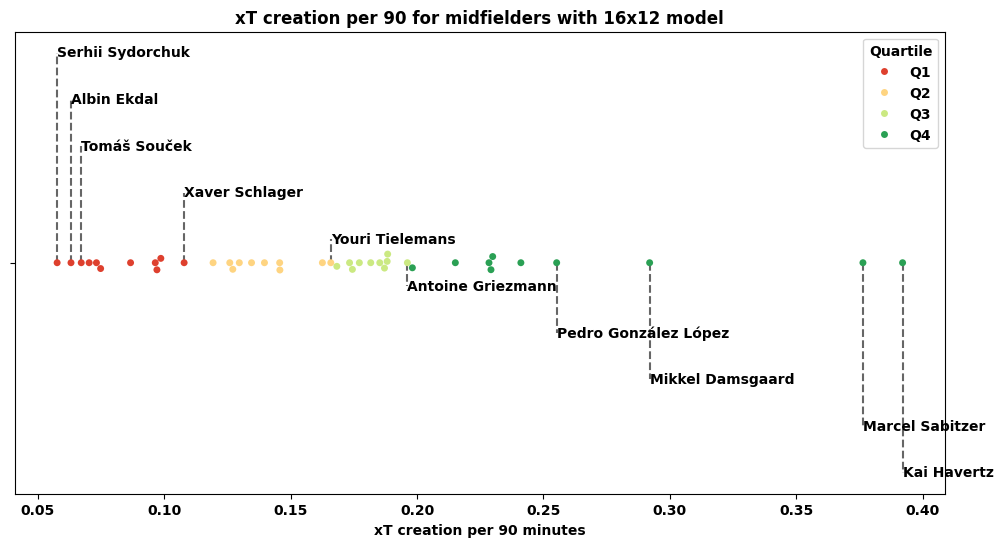

In [ ]:
# Determine quartile thresholds
q1 = midfielder_xT_df_32x24['action_xT_per_90'].quantile(0.25)
q2 = midfielder_xT_df_32x24['action_xT_per_90'].quantile(0.5)
q3 = midfielder_xT_df_32x24['action_xT_per_90'].quantile(0.75)

# Assign colors based on quartiles
def assign_quartile(value):
    if value <= q1:
        return 'Q1'
    elif value <= q2:
        return 'Q2'
    elif value <= q3:
        return 'Q3'
    else:
        return 'Q4'
    
cm = matplotlib.colormaps.get_cmap('RdYlGn')
palette_quartile = {
           'Q1': cm(0.125),
           'Q2': cm(0.375),
           'Q3': cm(0.625),
           'Q4': cm(0.875),
           }

print(f"There are {midfielder_xT_df_32x24['Player'].nunique()} unique midfielders in this data set.")
midfielder_xT_df_32x24['Quartile'] = midfielder_xT_df_32x24['action_xT_per_90'].apply(assign_quartile)

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(midfielder_xT_df_32x24) // 4, len(midfielder_xT_df_32x24) // 2, 3 * len(midfielder_xT_df_32x24) // 4, len(midfielder_xT_df_32x24) - 4, len(midfielder_xT_df_32x24) - 3, len(midfielder_xT_df_32x24) - 2, len(midfielder_xT_df_32x24) - 1]
key_players = midfielder_xT_df_32x24.iloc[key_indices]

# Create beeswarm plot
plt.figure(figsize=(12, 6))
ax = sns.swarmplot(x=midfielder_xT_df_32x24['action_xT_per_90'], orient='h', size=5, hue=midfielder_xT_df_32x24['Quartile'], palette=palette_quartile)

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    plt.plot([row['action_xT_per_90'], row['action_xT_per_90']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    plt.text(row['action_xT_per_90'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

plt.xlabel('xT creation per 90 minutes')
plt.title('xT creation per 90 for midfielders with 16x12 model')
plt.show()

## Look at difference between 16x12 and 64x48

In [ ]:
combined_player_xT_df = player_xT_df.rename(columns={'action_xT_per_90': 'action_xT_per_90_16x12'}).merge(player_xT_df_32x24.rename(columns={'action_xT_per_90': 'action_xT_per_90_32x24'})[['player_id', 'action_xT_per_90_32x24']], on='player_id')
combined_player_xT_df = combined_player_xT_df.merge(player_xT_df_64x48.rename(columns={'action_xT_per_90': 'action_xT_per_90_64x48'})[['player_id', 'action_xT_per_90_64x48']], on='player_id')
combined_player_xT_df['diff_action_xT_per_90'] = combined_player_xT_df['action_xT_per_90_64x48'] - combined_player_xT_df['action_xT_per_90_16x12']

,player_id,action_xT_sum,action_count,Player,Minutes,main_position,action_xT_per_90_16x12,Quartile,action_xT_per_90_32x24,action_xT_per_90_64x48,diff_action_xT_per_90
0,5205.0,0.065420,68,Rui Pedro dos Santos Patrício,379,goalkeeper,0.015535,Q1,0.015110,0.015173,-0.000362
1,5622.0,0.077652,58,Robin Olsen,411,goalkeeper,0.017004,Q1,0.016673,0.016872,-0.000132
2,5550.0,0.137401,112,Yann Sommer,536,goalkeeper,0.023071,Q1,0.022459,0.021728,-0.001343
3,22243.0,0.151637,99,Heorhii Bushchan,496,goalkeeper,0.027515,Q1,0.028256,0.027979,0.000465
4,11748.0,0.212080,204,Unai Simón Mendibil,658,goalkeeper,0.029008,Q1,0.028792,0.029190,0.000182
...,...,...,...,...,...,...,...,...,...,...,...
141,2988.0,1.403322,102,Memphis Depay,332,attacker,0.380419,Q4,0.392511,0.389606,0.009187
142,3382.0,2.545442,251,Luke Shaw,591,defender,0.387631,Q4,0.407906,0.408600,0.020969
143,6748.0,1.738343,85,Ferrán Torres García,373,attacker,0.419439,Q4,0.413007,0.435707,0.016268
144,3311.0,1.476453,295,Daley Blind,300,defender,0.442936,Q4,0.519068,0.604135,0.161199


In [ ]:
combined_midfielder_xT_df = combined_player_xT_df[combined_player_xT_df['main_position'] == 'midfielder'].sort_values('action_xT_per_90_16x12')
combined_midfielder_xT_df['Quartile'] = combined_midfielder_xT_df['action_xT_per_90_16x12'].apply(assign_quartile)
combined_midfielder_xT_df

,player_id,action_xT_sum,action_count,Player,Minutes,main_position,action_xT_per_90_16x12,Quartile,action_xT_per_90_32x24,action_xT_per_90_64x48,diff_action_xT_per_90
20,16514.0,0.232477,117,Serhii Sydorchuk,384,midfielder,0.054487,Q1,0.057614,0.060590,0.006103
25,5617.0,0.284656,55,Sebastian Larsson,383,midfielder,0.066890,Q1,0.073167,0.079687,0.012797
30,5624.0,0.337610,76,Albin Ekdal,402,midfielder,0.075584,Q1,0.063097,0.073045,-0.002539
31,3961.0,0.349330,190,N''Golo Kanté,415,midfielder,0.075758,Q1,0.074818,0.074454,-0.001304
34,4870.0,0.408551,155,Tomáš Souček,471,midfielder,0.078067,Q1,0.067150,0.065844,-0.012223
39,4706.0,0.618223,186,Kalvin Phillips,685,midfielder,0.081226,Q1,0.097089,0.094083,0.012857
41,10931.0,0.341527,97,Joe Allen,349,midfielder,0.088073,Q1,0.070270,0.073477,-0.014596
43,3943.0,0.531382,247,Declan Rice,541,midfielder,0.088400,Q1,0.086663,0.085121,-0.003279
44,5642.0,0.320679,147,Axel Witsel,322,midfielder,0.089631,Q1,0.096436,0.105100,0.015469
51,6983.0,0.604207,169,Remo Freuler,526,midfielder,0.103381,Q1,0.098635,0.094392,-0.008990


There were 146 players in the data set.


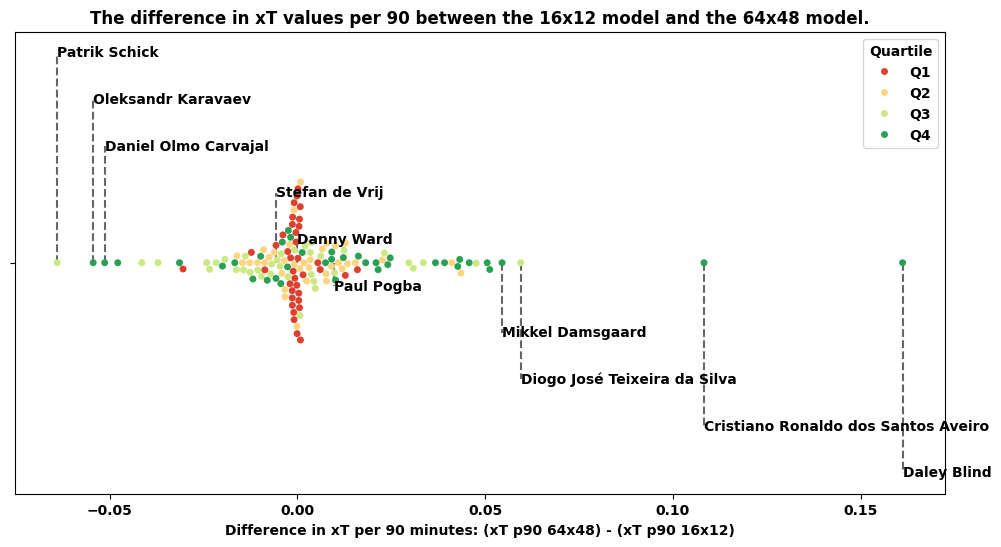

In [ ]:

# Sort values for annotation
combined_player_xT_df = combined_player_xT_df.sort_values('diff_action_xT_per_90')

# Give color palette for quartiles  
cm = matplotlib.colormaps.get_cmap('RdYlGn')
palette_quartile = {
           'Q1': cm(0.125),
           'Q2': cm(0.375),
           'Q3': cm(0.625),
           'Q4': cm(0.875),
           }


# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(player_xT_df) // 4, len(combined_player_xT_df) // 2, 3 * len(combined_player_xT_df) // 4, len(combined_player_xT_df) - 4, len(combined_player_xT_df) - 3, len(combined_player_xT_df) - 2, len(combined_player_xT_df) - 1]
key_players = combined_player_xT_df.iloc[key_indices]

print(f"There were {combined_player_xT_df.shape[0]} players in the data set.")

# Create beeswarm plot
plt.figure(figsize=(12, 6))
ax = sns.swarmplot(x=combined_player_xT_df['diff_action_xT_per_90'], orient='h', size=5, hue=combined_player_xT_df['Quartile'], palette=palette_quartile)

# Sort labels in legend
handles, labels = ax.get_legend_handles_labels()
sorted_labels = sorted(zip(handles, labels), key=lambda x: x[1])
sorted_handles, sorted_labels = zip(*sorted_labels)
plt.legend(sorted_handles, sorted_labels, title='Quartile')

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    plt.plot([row['diff_action_xT_per_90'], row['diff_action_xT_per_90']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    plt.text(row['diff_action_xT_per_90'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

plt.xlabel('Difference in xT per 90 minutes: (xT p90 64x48) - (xT p90 16x12)')
plt.title('The difference in xT values per 90 between the 16x12 model and the 64x48 model.')
plt.show()


In [ ]:

# Sort values for annotation
combined_player_xT_df = combined_player_xT_df.sort_values('diff_action_xT_per_90')

# Give color palette for quartiles  
cm = matplotlib.colormaps.get_cmap('RdYlGn')
palette_quartile = {
           'Q1': cm(0.125),
           'Q2': cm(0.375),
           'Q3': cm(0.625),
           'Q4': cm(0.875),
           }


# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(player_xT_df) // 4, len(combined_player_xT_df) // 2, 3 * len(combined_player_xT_df) // 4, len(combined_player_xT_df) - 4, len(combined_player_xT_df) - 3, len(combined_player_xT_df) - 2, len(combined_player_xT_df) - 1]
key_players = combined_player_xT_df.iloc[key_indices]

print(f"There were {combined_player_xT_df.shape[0]} players in the data set.")

# Create beeswarm plot
plt.figure(figsize=(12, 6))
ax = sns.swarmplot(x=combined_player_xT_df['diff_action_xT_per_90'], orient='h', size=5, hue=combined_player_xT_df['Quartile'], palette=palette_quartile)

# Sort labels in legend
handles, labels = ax.get_legend_handles_labels()
sorted_labels = sorted(zip(handles, labels), key=lambda x: x[1])
sorted_handles, sorted_labels = zip(*sorted_labels)
plt.legend(sorted_handles, sorted_labels, title='Quartile')

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    plt.plot([row['diff_action_xT_per_90'], row['diff_action_xT_per_90']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    plt.text(row['diff_action_xT_per_90'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

plt.xlabel('Difference in xT per 90 minutes: (xT p90 64x48) - (xT p90 16x12)')
plt.title('The difference in xT values per 90 between the 16x12 model and the 64x48 model.')
plt.show()


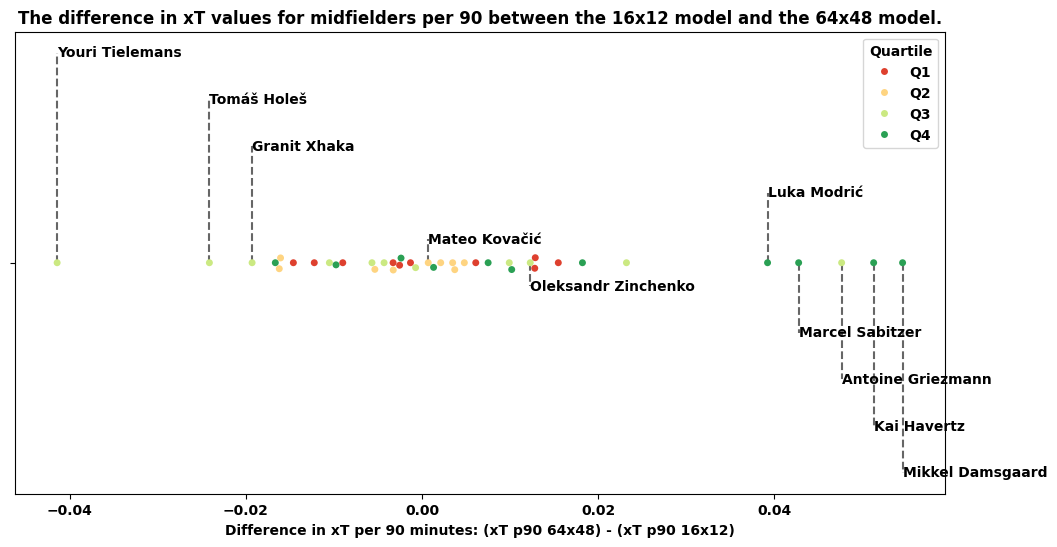

In [80]:

# Sort values for annotation
combined_midfielder_xT_df = combined_midfielder_xT_df.sort_values('diff_action_xT_per_90')

# Give color palette for quartiles  
cm = matplotlib.colormaps.get_cmap('RdYlGn')
palette_quartile = {
           'Q1': cm(0.125),
           'Q2': cm(0.375),
           'Q3': cm(0.625),
           'Q4': cm(0.875),
           }


# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(player_xT_df) // 4, len(combined_midfielder_xT_df) // 2, 3 * len(combined_midfielder_xT_df) // 4, len(combined_midfielder_xT_df) - 4, len(combined_midfielder_xT_df) - 3, len(combined_midfielder_xT_df) - 2, len(combined_midfielder_xT_df) - 1]
key_players = combined_midfielder_xT_df.iloc[key_indices]

# Create beeswarm plot
plt.figure(figsize=(12, 6))
ax = sns.swarmplot(x=combined_midfielder_xT_df['diff_action_xT_per_90'], orient='h', size=5, hue=combined_midfielder_xT_df['Quartile'], palette=palette_quartile)

# Sort labels in legend
handles, labels = ax.get_legend_handles_labels()
sorted_labels = sorted(zip(handles, labels), key=lambda x: x[1])
sorted_handles, sorted_labels = zip(*sorted_labels)
plt.legend(sorted_handles, sorted_labels, title='Quartile')

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    plt.plot([row['diff_action_xT_per_90'], row['diff_action_xT_per_90']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    plt.text(row['diff_action_xT_per_90'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

plt.xlabel('Difference in xT per 90 minutes: (xT p90 64x48) - (xT p90 16x12)')
plt.title('The difference in xT values for midfielders per 90 between the 16x12 model and the 64x48 model.')
plt.show()


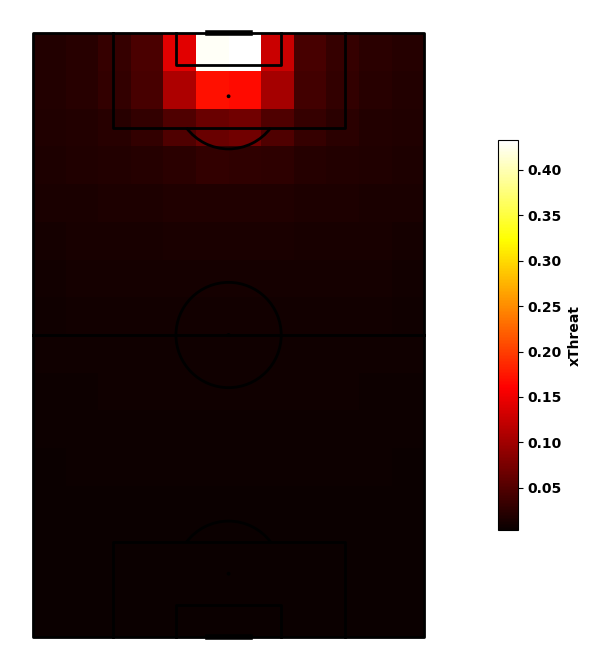

0.4324319332941827


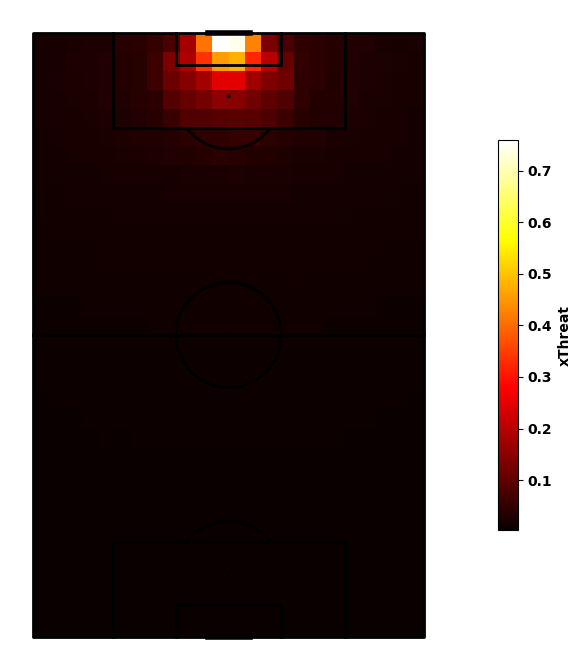

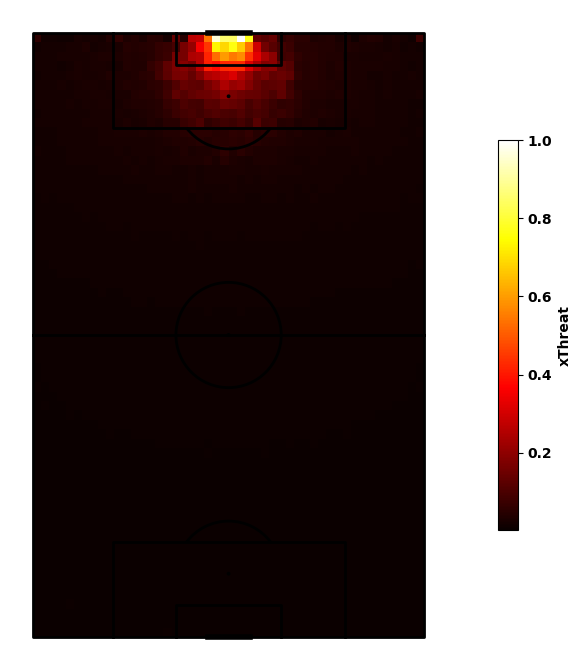

In [ ]:
xT_true_16x12.plot_xThreat()
print(xT_true_16x12.xT.max())
xT_true_32x24.plot_xThreat()
xT_true_64x48.plot_xThreat()

# Resampled models

In [ ]:
df_errors = pd.read_csv('../2-calculate-values/bootstrap_errors_normal_xthreat.csv').rename(columns={'sample_size': 'N'})
df_errors['M'] = df_errors['n_x'] * df_errors['n_y']
df_errors['1/sqrt(N)'] = 1/np.sqrt(df_errors['N'])
df_errors['Mlog(M)/sqrt(N)'] = df_errors['M']*np.log(df_errors['M'])*df_errors['1/sqrt(N)']

# Make the norm a dimension independent norm
for col in df_errors.columns.tolist():
    if '1_norm' in col:
        df_errors[col] = df_errors[col]/df_errors['M']
    if ' 2_norm' in col:
        df_errors[col] = df_errors[col]/np.sqrt(df_errors['M'])

In [ ]:
df_errors

,n_x,n_y,N,i_bootstrap,random_state,xT_error_1_norm,g_error_1_norm,xG_error_1_norm,prob_shot_error_1_norm,transition_matrix_error_1_norm,...,xT_error_inf_norm,g_error_inf_norm,xG_error_inf_norm,prob_shot_error_inf_norm,transition_matrix_error_inf_norm,transition_matrix_true_inf_norm,transition_matrix_resampled_inf_norm,M,1/sqrt(N),Mlog(M)/sqrt(N)
0,16,12,4000000,0,5176042,0.000561,0.000314,0.007967,0.000580,0.000403,...,0.012561,0.010799,0.500000,0.022223,0.131414,1.0,1.0,192,0.000500,0.504720
1,16,12,4000000,1,5176043,0.000338,0.000166,0.006788,0.000344,0.000401,...,0.012944,0.010130,0.500000,0.008385,0.117864,1.0,1.0,192,0.000500,0.504720
2,16,12,4000000,2,5176044,0.000370,0.000248,0.009014,0.000351,0.000414,...,0.010126,0.011958,0.500000,0.006650,0.132075,1.0,1.0,192,0.000500,0.504720
3,16,12,4000000,3,5176045,0.000605,0.000350,0.005589,0.000430,0.000438,...,0.017236,0.015174,0.157143,0.011811,0.133729,1.0,1.0,192,0.000500,0.504720
4,16,12,4000000,4,5176046,0.000337,0.000259,0.008731,0.000483,0.000433,...,0.015648,0.017580,0.500000,0.012102,0.139206,1.0,1.0,192,0.000500,0.504720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,64,48,100000,995,4805037,0.010060,0.007286,0.024008,0.013091,0.001156,...,1.000000,1.000000,1.000000,1.000000,1.928571,1.0,1.0,3072,0.003162,78.008388
47996,64,48,100000,996,4805038,0.008690,0.006119,0.023058,0.011962,0.001202,...,1.000000,1.000000,1.000000,1.000000,1.884615,1.0,1.0,3072,0.003162,78.008388
47997,64,48,100000,997,4805039,0.009090,0.006422,0.022428,0.012409,0.001110,...,0.958333,0.920000,1.000000,1.000000,1.865385,1.0,1.0,3072,0.003162,78.008388
47998,64,48,100000,998,4805040,0.010046,0.006882,0.023307,0.012695,0.001056,...,1.000000,1.000000,1.000000,1.000000,1.879518,1.0,1.0,3072,0.003162,78.008388


In [ ]:
df_errors[(df_errors['n_x'] == 16) & (df_errors['N'] == 630_000) & (df_errors['i_bootstrap'] == 900)][['xT_error_1_norm', 'xT_error_inf_norm', 'Mlog(M)/sqrt(N)']]

,xT_error_1_norm,xT_error_inf_norm,Mlog(M)/sqrt(N)
2900,0.001121,0.022994,1.271774


In [ ]:
df_errors[(df_errors['n_x'] == 64) & (df_errors['N'] == 630_000) & (df_errors['i_bootstrap'] == 906)][['xT_error_1_norm', 'xT_error_inf_norm', 'Mlog(M)/sqrt(N)']]

,xT_error_1_norm,xT_error_inf_norm,Mlog(M)/sqrt(N)
42906,0.003632,0.538462,31.079286


In [ ]:
df_errors[(df_errors['n_x'] == 32) & (df_errors['N'] == 4_000_000) & (df_errors['i_bootstrap'] == 900)][['xT_error_1_norm', 'xT_error_inf_norm', 'Mlog(M)/sqrt(N)']]

,xT_error_1_norm,xT_error_inf_norm,Mlog(M)/sqrt(N)
8900,0.000618,0.026991,2.551215


## Resampled 16x12 (630 000 events)

In [ ]:
xT_resampled_16x12 = xThreat.load_from_pickle('../0-model-storage/xt-N630000-n_x16-n_y12-i_bootstrap900-random_state1806942.pickle')

(<Figure size 1050x680 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x2c71e17dd30>)

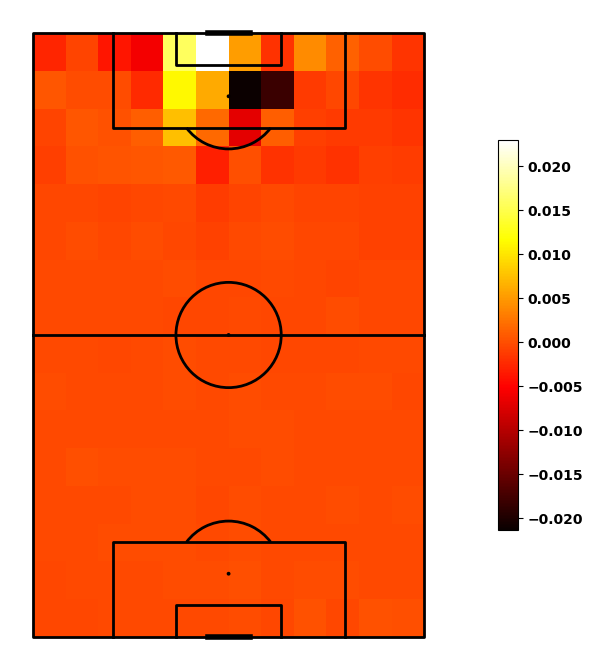

In [ ]:
xT_resampled_16x12.plot_pitch_heatmap(xT_resampled_16x12.xT - xT_true_16x12.xT)

## Resampled 64x48 (630 000 events)

In [ ]:
xT_resampled_64x48 = xThreat.load_from_pickle('../0-model-storage/xt-N630000-n_x64-n_y48-i_bootstrap906-random_state5334948.pickle')

(<Figure size 1050x680 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x2c718980260>)

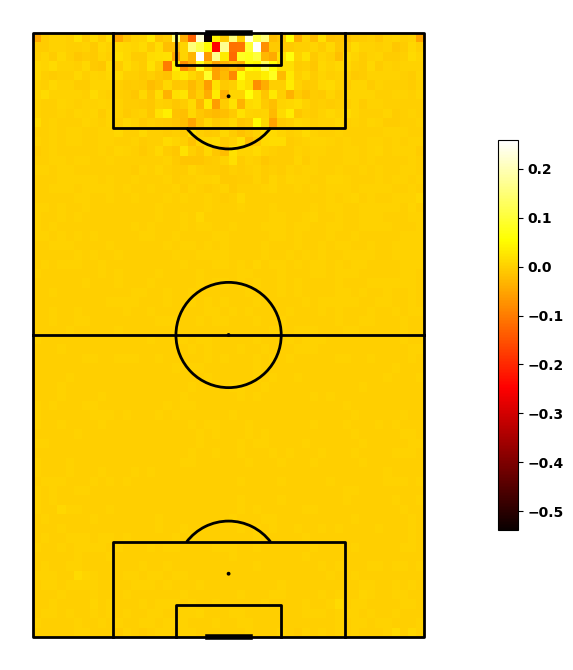

In [ ]:
xT_resampled_64x48.plot_pitch_heatmap(xT_resampled_64x48.xT - xT_true_64x48.xT)

## Resampled 64x48 (630 000 events)

In [ ]:
xT_resampled_32x24 = xThreat.load_from_pickle('../0-model-storage/xt-N4000000-n_x32-n_y24-i_bootstrap900-random_state6352942.pickle')

(<Figure size 1050x680 with 2 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x2c7189a7110>)

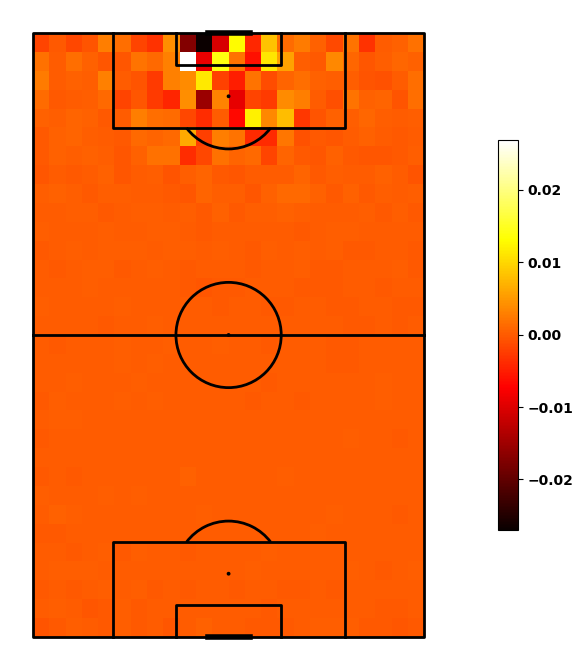

In [ ]:
xT_resampled_32x24.plot_pitch_heatmap(xT_resampled_32x24.xT - xT_true_32x24.xT)

## Calculate resampled xT values

In [ ]:
df_euros_filtered_resampled_16x12 = xT_resampled_16x12.quantify_action_quality(df_euros_filtered)
df_positive_resampled_16x12 = df_euros_filtered_resampled_16x12[df_euros_filtered_resampled_16x12['action_xT'] > 0]
df_positive_resampled_16x12 = df_positive_resampled_16x12.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
df_positive_resampled_16x12['action_xT_sum'] = df_positive_resampled_16x12['action_xT']
df_positive_resampled_16x12['action_xT'] = df_positive_resampled_16x12['action_xT'] / df_positive_resampled_16x12['Minutes'] * 90

player_xT_df_resampled_16x12 = pd.DataFrame(df_positive_resampled_16x12.groupby('player_id')['action_xT'].sum()).rename(columns={'action_xT': 'action_xT_resampled_16x12'})
player_xT_df_resampled_16x12

,action_xT_resampled_16x12
player_id,
2954.0,0.183975
2988.0,0.363154
2999.0,0.111404
3009.0,0.156289
3026.0,0.125993
...,...
30328.0,0.082529
30486.0,0.241959
31900.0,0.260357


In [ ]:
df_euros_filtered_resampled_64x48 = xT_resampled_64x48.quantify_action_quality(df_euros_filtered)
df_positive_resampled_64x48 = df_euros_filtered_resampled_64x48[df_euros_filtered_resampled_64x48['action_xT'] > 0]
df_positive_resampled_64x48 = df_positive_resampled_64x48.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
df_positive_resampled_64x48['action_xT_sum'] = df_positive_resampled_64x48['action_xT']
df_positive_resampled_64x48['action_xT'] = df_positive_resampled_64x48['action_xT'] / df_positive_resampled_64x48['Minutes'] * 90
player_xT_df_resampled_64x48 = pd.DataFrame(df_positive_resampled_64x48.groupby('player_id')['action_xT'].sum()).rename(columns={'action_xT': 'action_xT_resampled_64x48'})
player_xT_df_resampled_64x48

,action_xT_resampled_64x48
player_id,
2954.0,0.156986
2988.0,0.377739
2999.0,0.136456
3009.0,0.153320
3026.0,0.132862
...,...
30328.0,0.095613
30486.0,0.263609
31900.0,0.225403


In [ ]:
df_euros_filtered_resampled_32x24 = xT_resampled_32x24.quantify_action_quality(df_euros_filtered)
df_positive_resampled_32x24 = df_euros_filtered_resampled_32x24[df_euros_filtered_resampled_32x24['action_xT'] > 0]
df_positive_resampled_32x24 = df_positive_resampled_32x24.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
df_positive_resampled_32x24['action_xT_sum'] = df_positive_resampled_32x24['action_xT']
df_positive_resampled_32x24['action_xT'] = df_positive_resampled_32x24['action_xT'] / df_positive_resampled_32x24['Minutes'] * 90
player_xT_df_resampled_32x24 = pd.DataFrame(df_positive_resampled_32x24.groupby('player_id')['action_xT'].sum()).rename(columns={'action_xT': 'action_xT_resampled_32x24'})
player_xT_df_resampled_32x24

,action_xT_resampled_32x24
player_id,
2954.0,0.163544
2988.0,0.397179
2999.0,0.130969
3009.0,0.161359
3026.0,0.123580
...,...
30328.0,0.093832
30486.0,0.258754
31900.0,0.219881


In [ ]:
combined_player_xT_df

,player_id,action_xT_16x12,action_xT_count,Player,color,action_xT_64x48,action_xT_32x24,diff_xT
103,7044.0,0.181979,55,Patrik Schick,"(0.7333333333333335, 0.8865051903114187, 0.468...",0.118023,0.152334,-0.063956
120,31900.0,0.242756,181,Oleksandr Karavaev,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.188396,0.229077,-0.054359
123,16532.0,0.259927,113,Daniel Olmo Carvajal,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.208644,0.215694,-0.051283
132,8286.0,0.306989,150,Leonardo Spinazzola,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.259186,0.283593,-0.047804
108,2954.0,0.186994,124,Youri Tielemans,"(0.7333333333333335, 0.8865051903114187, 0.468...",0.145590,0.165869,-0.041404
...,...,...,...,...,...,...,...,...
136,8966.0,0.336375,81,Kai Havertz,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.387633,0.392047,0.051257
131,24443.0,0.298068,87,Mikkel Damsgaard,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.352608,0.291989,0.054540
87,9929.0,0.145205,65,Diogo José Teixeira da Silva,"(0.7333333333333335, 0.8865051903114187, 0.468...",0.204691,0.162757,0.059486
138,5207.0,0.343320,70,Cristiano Ronaldo dos Santos Aveiro,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.451639,0.383099,0.108320


In [ ]:
combined_player_xT_df = combined_player_xT_df.merge(player_xT_df_resampled_16x12, on='player_id', how='left')
combined_player_xT_df = combined_player_xT_df.merge(player_xT_df_resampled_64x48, on='player_id', how='left')
combined_player_xT_df = combined_player_xT_df.merge(player_xT_df_resampled_32x24, on='player_id', how='left')

In [ ]:
combined_player_xT_df

,player_id,action_xT_16x12,action_xT_count,Player,color,action_xT_64x48,action_xT_32x24,diff_xT,action_xT_resampled_16x12,action_xT_resampled_64x48,action_xT_resampled_32x24
0,7044.0,0.181979,55,Patrik Schick,"(0.7333333333333335, 0.8865051903114187, 0.468...",0.118023,0.152334,-0.063956,0.193690,0.131506,0.153000
1,31900.0,0.242756,181,Oleksandr Karavaev,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.188396,0.229077,-0.054359,0.260357,0.225403,0.219881
2,16532.0,0.259927,113,Daniel Olmo Carvajal,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.208644,0.215694,-0.051283,0.248619,0.226849,0.208803
3,8286.0,0.306989,150,Leonardo Spinazzola,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.259186,0.283593,-0.047804,0.297178,0.317463,0.283047
4,2954.0,0.186994,124,Youri Tielemans,"(0.7333333333333335, 0.8865051903114187, 0.468...",0.145590,0.165869,-0.041404,0.183975,0.156986,0.163544
...,...,...,...,...,...,...,...,...,...,...,...
141,8966.0,0.336375,81,Kai Havertz,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.387633,0.392047,0.051257,0.339003,0.368477,0.400956
142,24443.0,0.298068,87,Mikkel Damsgaard,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.352608,0.291989,0.054540,0.297101,0.399537,0.291262
143,9929.0,0.145205,65,Diogo José Teixeira da Silva,"(0.7333333333333335, 0.8865051903114187, 0.468...",0.204691,0.162757,0.059486,0.155087,0.268564,0.169014
144,5207.0,0.343320,70,Cristiano Ronaldo dos Santos Aveiro,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.451639,0.383099,0.108320,0.350996,0.483644,0.388044


In [ ]:
combined_player_xT_df['diff_xT_16x12'] = combined_player_xT_df['action_xT_16x12'] - combined_player_xT_df['action_xT_resampled_16x12']
combined_player_xT_df['diff_xT_32x24'] = combined_player_xT_df['action_xT_32x24'] - combined_player_xT_df['action_xT_resampled_32x24']
combined_player_xT_df['diff_xT_64x48'] = combined_player_xT_df['action_xT_64x48'] - combined_player_xT_df['action_xT_resampled_64x48']
combined_player_xT_df

,player_id,action_xT_16x12,action_xT_count,Player,color,action_xT_64x48,action_xT_32x24,diff_xT,action_xT_resampled_16x12,action_xT_resampled_64x48,action_xT_resampled_32x24,diff_xT_16x12,diff_xT_32x24,diff_xT_64x48
0,7044.0,0.181979,55,Patrik Schick,"(0.7333333333333335, 0.8865051903114187, 0.468...",0.118023,0.152334,-0.063956,0.193690,0.131506,0.153000,-0.011711,-0.000666,-0.013484
1,31900.0,0.242756,181,Oleksandr Karavaev,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.188396,0.229077,-0.054359,0.260357,0.225403,0.219881,-0.017601,0.009197,-0.037007
2,16532.0,0.259927,113,Daniel Olmo Carvajal,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.208644,0.215694,-0.051283,0.248619,0.226849,0.208803,0.011308,0.006891,-0.018204
3,8286.0,0.306989,150,Leonardo Spinazzola,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.259186,0.283593,-0.047804,0.297178,0.317463,0.283047,0.009812,0.000546,-0.058277
4,2954.0,0.186994,124,Youri Tielemans,"(0.7333333333333335, 0.8865051903114187, 0.468...",0.145590,0.165869,-0.041404,0.183975,0.156986,0.163544,0.003019,0.002325,-0.011396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,8966.0,0.336375,81,Kai Havertz,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.387633,0.392047,0.051257,0.339003,0.368477,0.400956,-0.002628,-0.008909,0.019155
142,24443.0,0.298068,87,Mikkel Damsgaard,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.352608,0.291989,0.054540,0.297101,0.399537,0.291262,0.000967,0.000726,-0.046929
143,9929.0,0.145205,65,Diogo José Teixeira da Silva,"(0.7333333333333335, 0.8865051903114187, 0.468...",0.204691,0.162757,0.059486,0.155087,0.268564,0.169014,-0.009882,-0.006257,-0.063873
144,5207.0,0.343320,70,Cristiano Ronaldo dos Santos Aveiro,"(0.0, 0.40784313725490196, 0.21568627450980393...",0.451639,0.383099,0.108320,0.350996,0.483644,0.388044,-0.007677,-0.004944,-0.032005


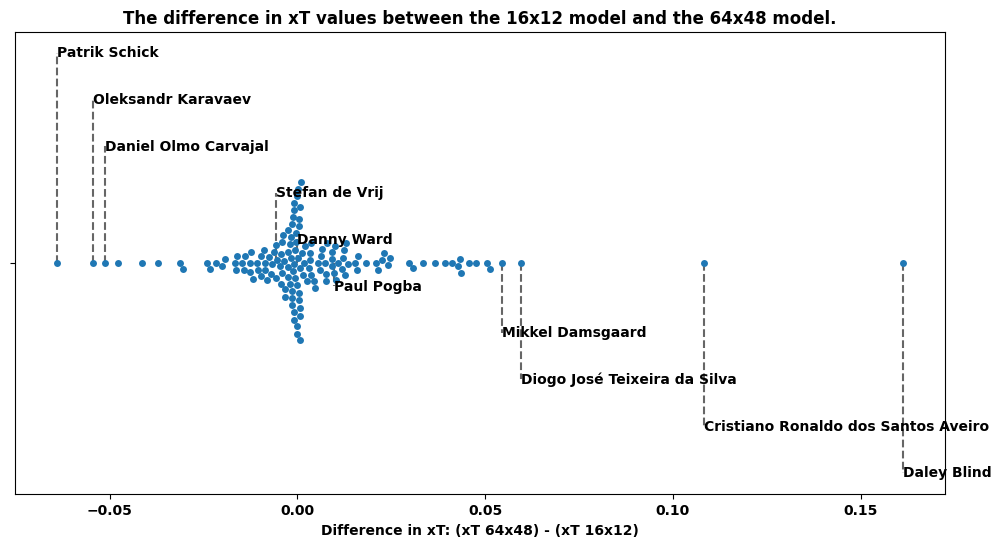

In [ ]:
import numpy as np

# Sort values for annotation
combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT')

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(player_xT_df) // 4, len(combined_player_xT_df) // 2, 3 * len(combined_player_xT_df) // 4, len(combined_player_xT_df) - 4, len(combined_player_xT_df) - 3, len(combined_player_xT_df) - 2, len(combined_player_xT_df) - 1]
key_players = combined_player_xT_df.iloc[key_indices]

# Create beeswarm plot
plt.figure(figsize=(12, 6))
ax = sns.swarmplot(x=combined_player_xT_df['diff_xT'], orient='h', size=5)

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    plt.plot([row['diff_xT'], row['diff_xT']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    plt.text(row['diff_xT'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

plt.xlabel('Difference in xT: (xT 64x48) - (xT 16x12)')
plt.title('The difference in xT values between the 16x12 model and the 64x48 model.')
plt.show()


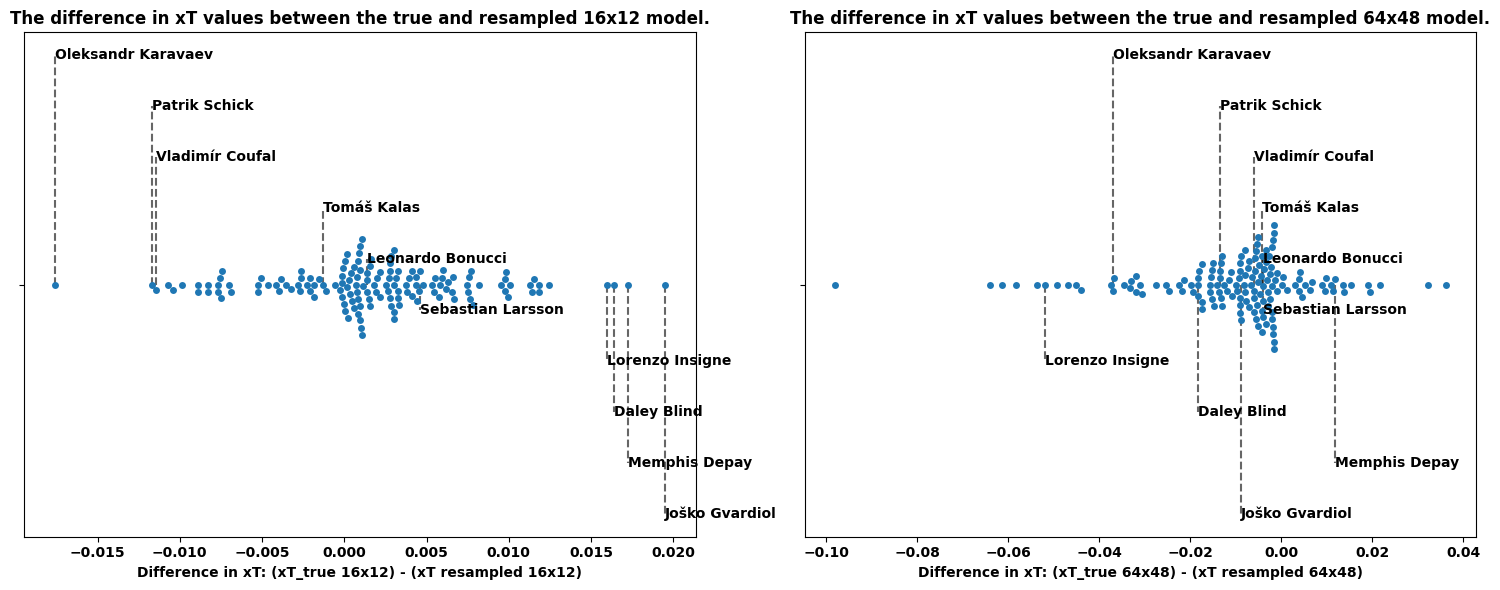

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sort values for annotation
combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT_16x12')

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(combined_player_xT_df) // 4, len(combined_player_xT_df) // 2, 3 * len(combined_player_xT_df) // 4, len(combined_player_xT_df) - 4, len(combined_player_xT_df) - 3, len(combined_player_xT_df) - 2, len(combined_player_xT_df) - 1]
key_players = combined_player_xT_df.iloc[key_indices]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # 1 row, 2 columns


# Create beeswarm plot
sns.swarmplot(x=combined_player_xT_df['diff_xT_16x12'], orient='h', size=5, ax=axes[0])

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    axes[0].plot([row['diff_xT_16x12'], row['diff_xT_16x12']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    axes[0].text(row['diff_xT_16x12'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

axes[0].set_xlabel('Difference in xT: (xT_true 16x12) - (xT resampled 16x12)')
axes[0].set_title('The difference in xT values between the true and resampled 16x12 model.')


# Sort values for annotation
combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT_64x48')
# Create beeswarm plot
sns.swarmplot(x=combined_player_xT_df['diff_xT_64x48'], orient='h', size=5, ax=axes[1])

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    axes[1].plot([row['diff_xT_64x48'], row['diff_xT_64x48']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    axes[1].text(row['diff_xT_64x48'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

axes[1].set_xlabel('Difference in xT: (xT_true 64x48) - (xT resampled 64x48)')
axes[1].set_title('The difference in xT values between the true and resampled 64x48 model.')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


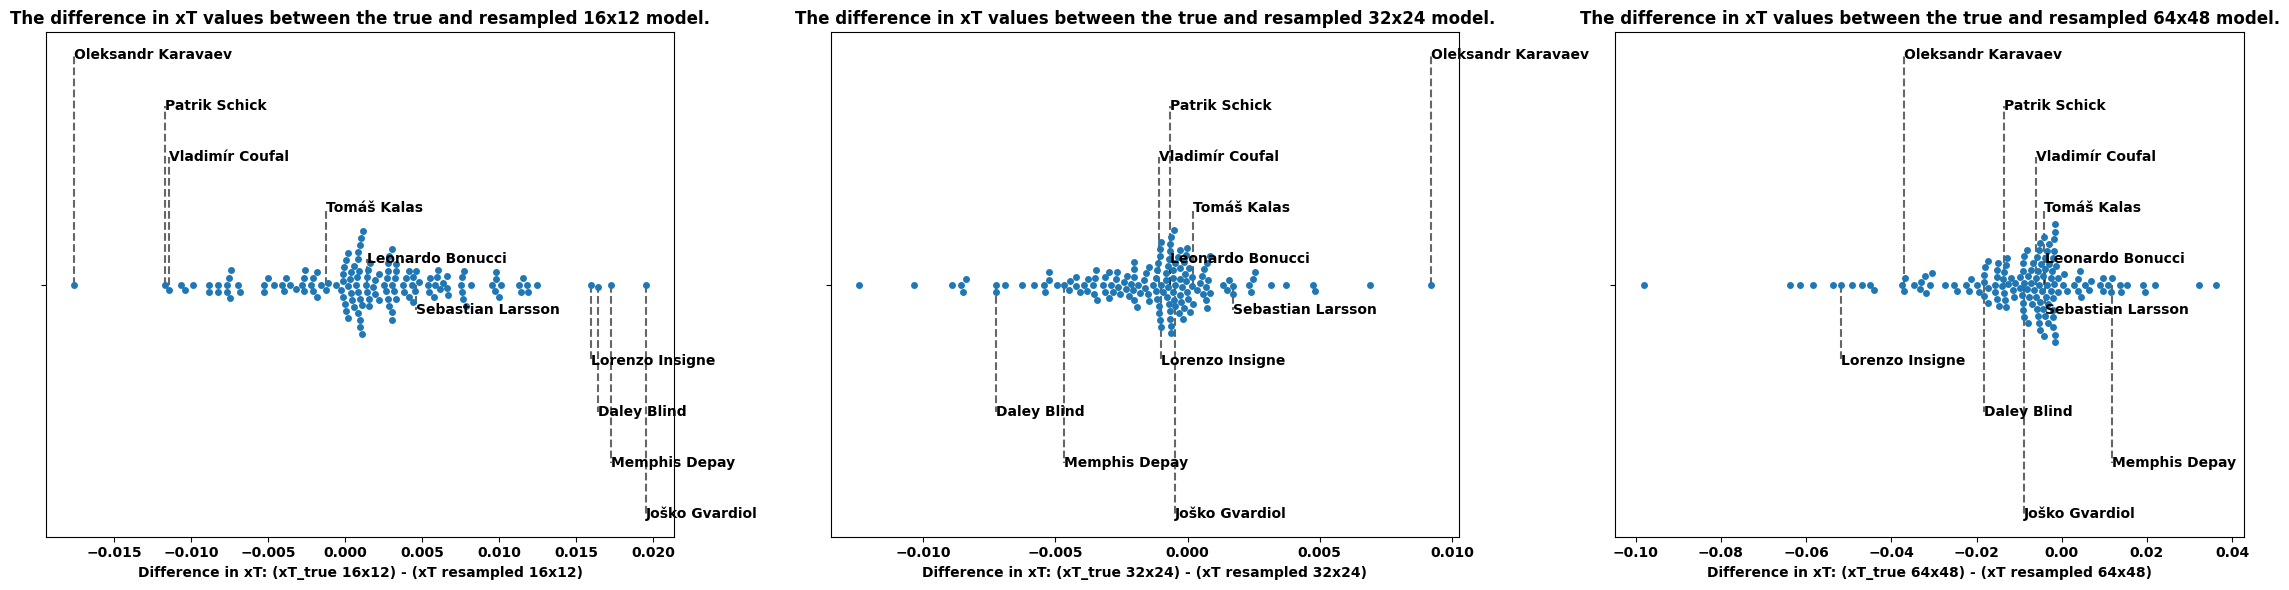

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sort values for annotation
combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT_16x12')

# Select some key points for annotation: min, max, and quartiles
key_indices = [0, 1, 2, len(combined_player_xT_df) // 4, len(combined_player_xT_df) // 2, 3 * len(combined_player_xT_df) // 4, len(combined_player_xT_df) - 4, len(combined_player_xT_df) - 3, len(combined_player_xT_df) - 2, len(combined_player_xT_df) - 1]
key_players = combined_player_xT_df.iloc[key_indices]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(22.5, 6))  # 1 row, 2 columns

# Create beeswarm plot
sns.swarmplot(x=combined_player_xT_df['diff_xT_16x12'], orient='h', size=5, ax=axes[0])

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    axes[0].plot([row['diff_xT_16x12'], row['diff_xT_16x12']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    axes[0].text(row['diff_xT_16x12'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

axes[0].set_xlabel('Difference in xT: (xT_true 16x12) - (xT resampled 16x12)')
axes[0].set_title('The difference in xT values between the true and resampled 16x12 model.')


# Sort values for annotation
combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT_32x24')
# Create beeswarm plot
sns.swarmplot(x=combined_player_xT_df['diff_xT_32x24'], orient='h', size=5, ax=axes[1])

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    axes[1].plot([row['diff_xT_32x24'], row['diff_xT_32x24']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    axes[1].text(row['diff_xT_32x24'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

axes[1].set_xlabel('Difference in xT: (xT_true 32x24) - (xT resampled 32x24)')
axes[1].set_title('The difference in xT values between the true and resampled 32x24 model.')


# Sort values for annotation
combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT_64x48')
# Create beeswarm plot
sns.swarmplot(x=combined_player_xT_df['diff_xT_64x48'], orient='h', size=5, ax=axes[2])

# Annotate selected points with lines and staggered text positions
y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
for i, (_, row) in enumerate(key_players.iterrows()):
    axes[2].plot([row['diff_xT_64x48'], row['diff_xT_64x48']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
    axes[2].text(row['diff_xT_64x48'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

axes[2].set_xlabel('Difference in xT: (xT_true 64x48) - (xT resampled 64x48)')
axes[2].set_title('The difference in xT values between the true and resampled 64x48 model.')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()